Dataset Shape: (51290, 27)

Columns:

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

Data Types:

Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
记录数                 int64
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     

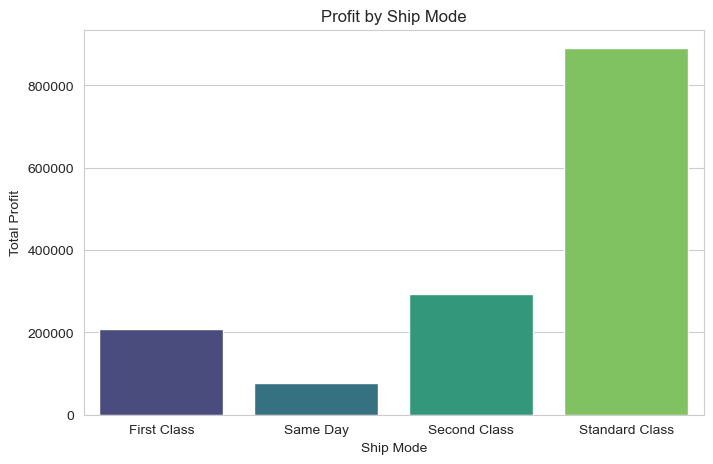

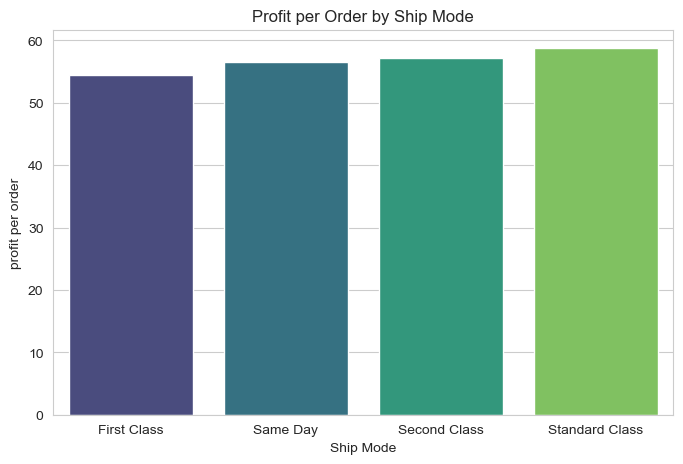

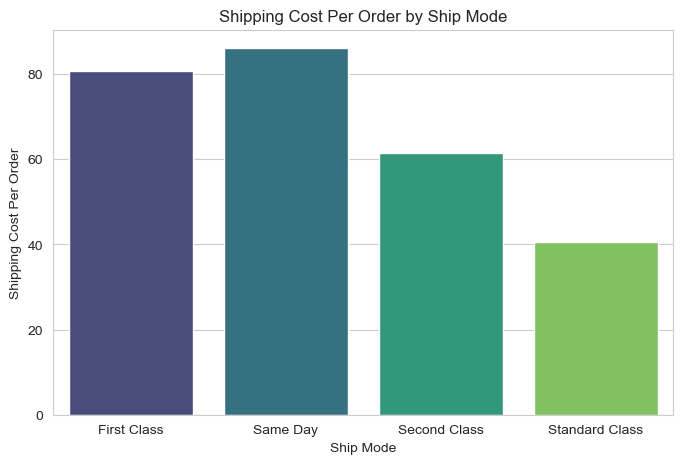

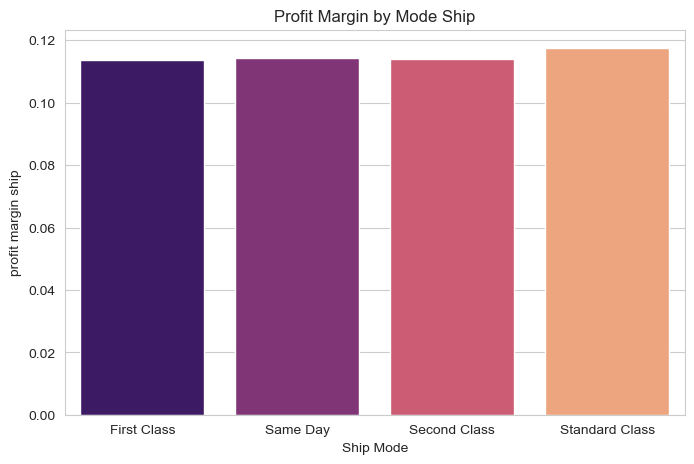

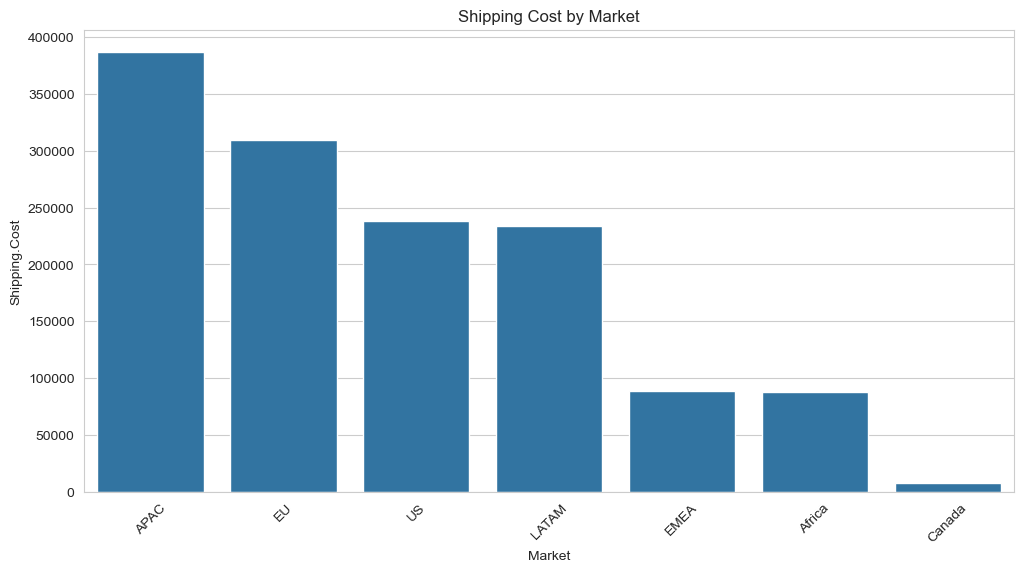

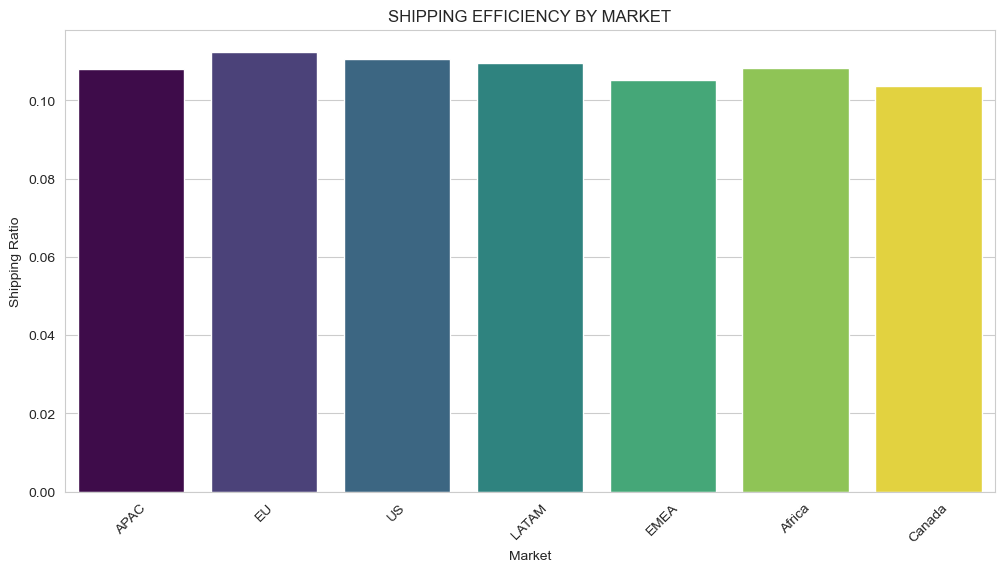

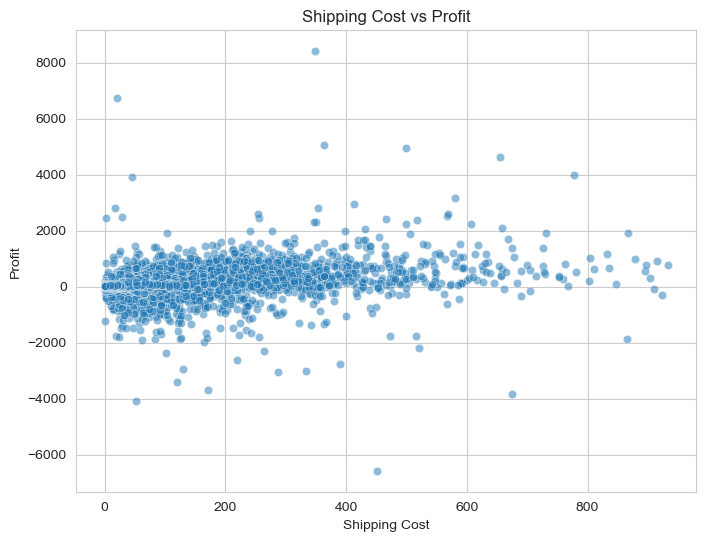

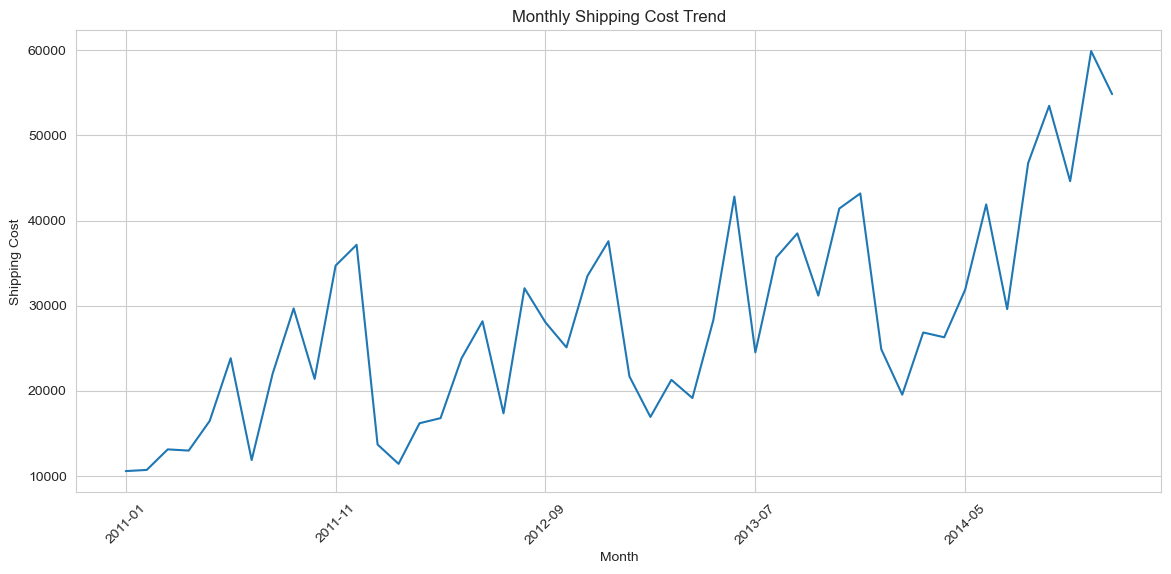

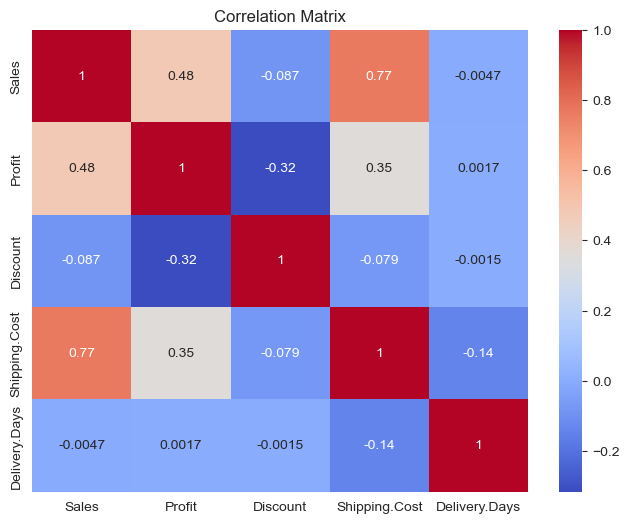

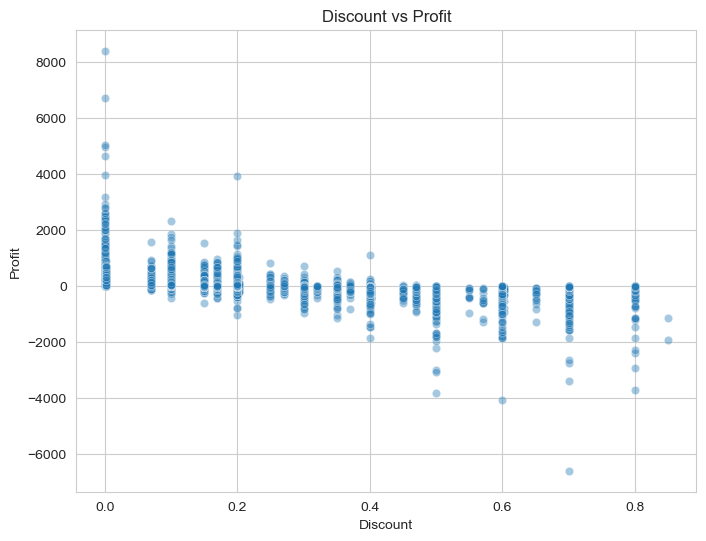

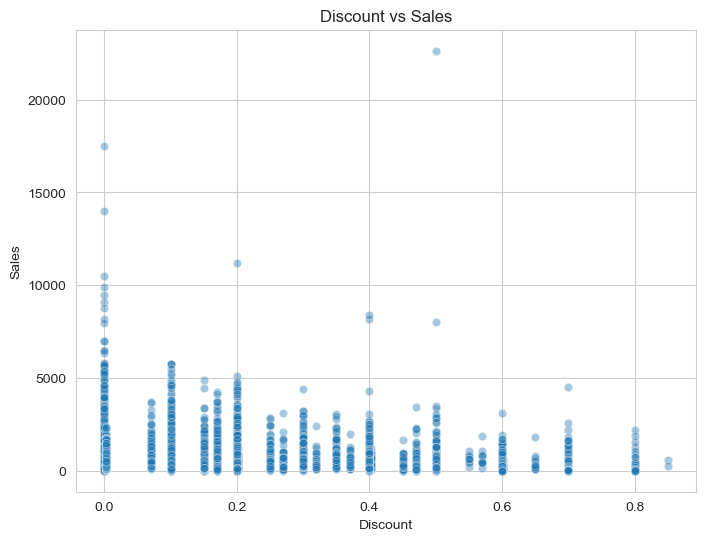

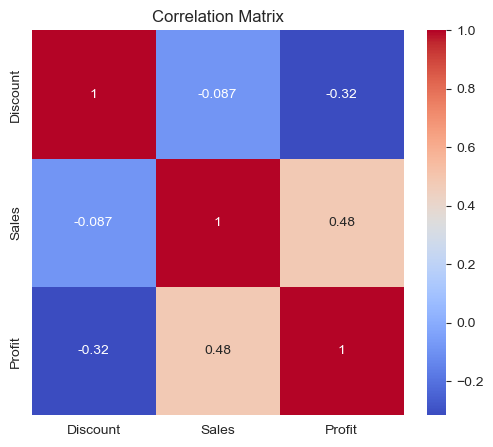

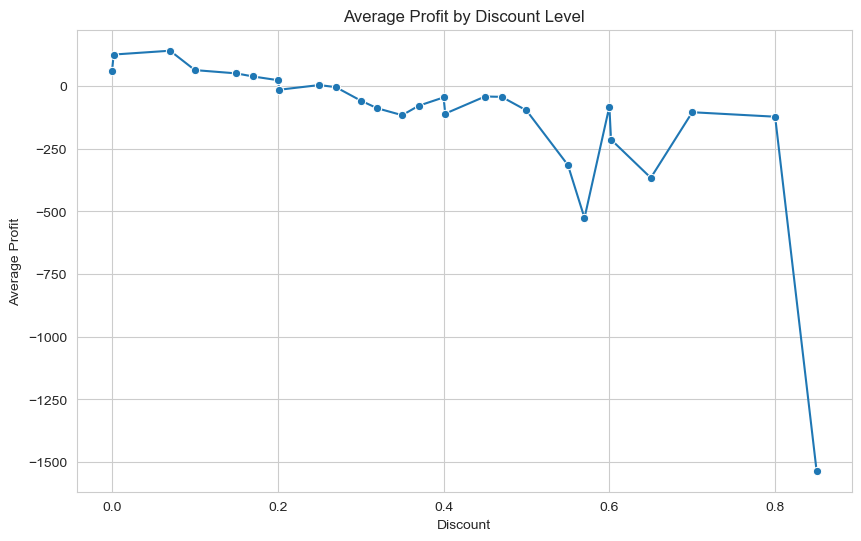

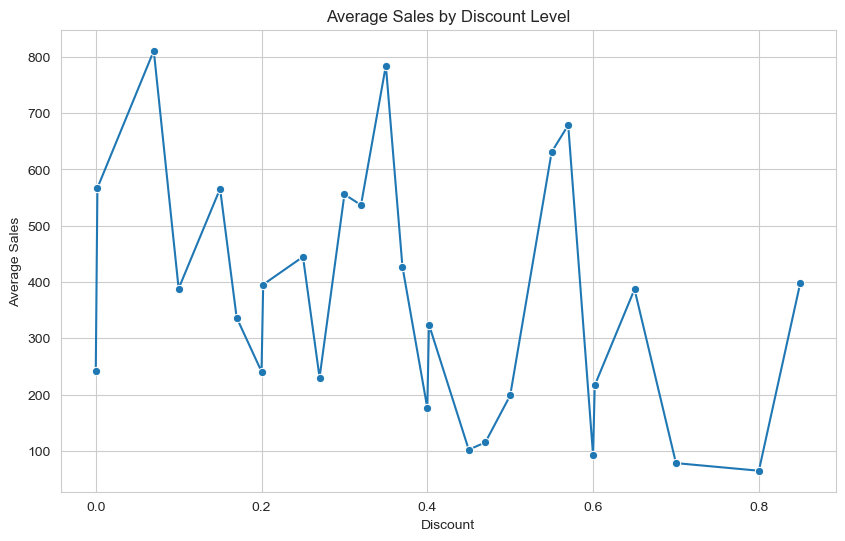

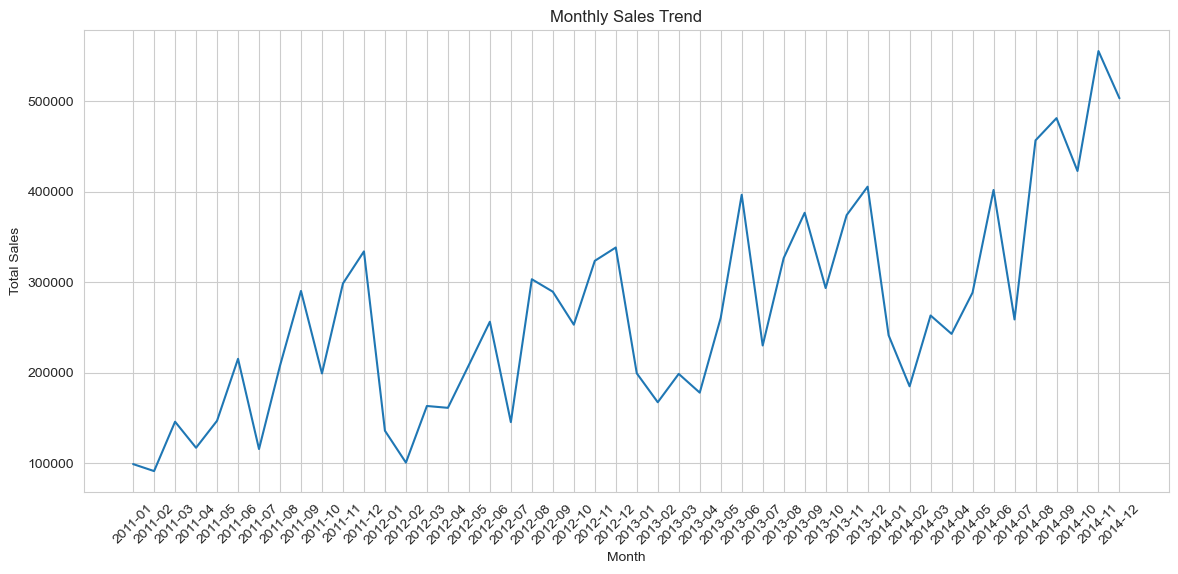

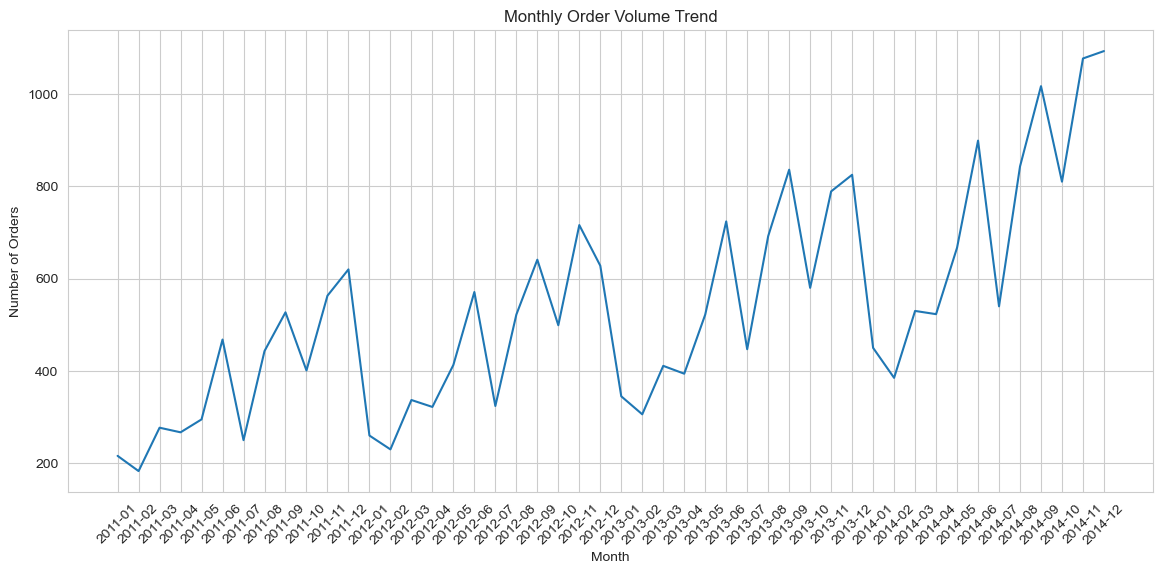

In [14]:
# ============================================
# GLOBAL SUPERSTORE - SHIPPING COST ANALYSIS
# ============================================

# --------------------------------------------
# 1. Import Libraries
# --------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
pd.set_option('display.max_columns', None)

# Style
sns.set_style("whitegrid")

# --------------------------------------------
# 2. Load Dataset
# --------------------------------------------

# The data
df = pd.read_csv('data/superstore.csv')

# Preview data
df.head()

# --------------------------------------------
# 3. Basic Data Exploration
# --------------------------------------------

# Shape of dataset
print("Dataset Shape:", df.shape)

# Columns
print("\nColumns:\n")
print(df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# --------------------------------------------
# 4. Handling data types
# --------------------------------------------

date_type = ['Order.Date','Ship.Date']
df[date_type] = df[date_type].apply(pd.to_datetime,errors='coerce')

# Check
df[date_type].dtypes

# Rename the 记录数 column
df.rename(columns={'记录数': 'Record Count'}, inplace=True)


# --------------------------------------------
# 5. Create New Features
# --------------------------------------------

# Delivery Time
df['Delivery.Days'] = (df['Ship.Date'] - df['Order.Date']).dt.days

# Shipping Cost Ratio
df['Shipping.Ratio'] = df['Shipping.Cost'] / df['Sales']

# Profit Margin
df['Profit.Margin'] = df['Profit'] / df['Sales']

# check
df.head()

# --------------------------------------------
# 6. General KPIs
# --------------------------------------------

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_shipping = df['Shipping.Cost'].sum()
avg_shipping = df['Shipping.Cost'].mean()

print("Total Sales: ", round(total_sales, 2))
print("Total Profit: ", round(total_profit, 2))
print("Total Shipping Cost: ", round(total_shipping, 2))
print("Average Shipping Cost: ", round(avg_shipping, 2))

# --------------------------------------------
# 7. Shipping Cost by Ship Mode
# --------------------------------------------

ship_mode_analysis = df.groupby('Ship.Mode').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Shipping.Cost': 'sum',
    'Order.ID': 'count'
}).reset_index()

ship_mode_analysis

# --------------------------------------------
# 7.1 . Visualization - Profit by Ship Mode
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=ship_mode_analysis,
    x='Ship.Mode',
    y='Profit',
    hue='Ship.Mode',  # ربط الألوان بالفئات
    palette='viridis', # اختيار مجموعة ألوان (اختياري)
    legend=False       # لإخفاء مربّع التوضيح بما أن الأسماء موجودة أسفل الأعمدة
)

plt.title('Profit by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Profit')

plt.show()

# --------------------------------------------
# 7.2 . Profit by Order
# --------------------------------------------

profit_per_order = df.groupby('Ship.Mode').agg({
    'Profit': 'sum',
    'Order.ID': 'nunique'
}).reset_index()

profit_per_order['Profit.Per.Order'] = (
    profit_per_order['Profit'] /
    profit_per_order['Order.ID']
)

profit_per_order.sort_values(
    by='Profit.Per.Order',
    ascending=False
)

# --------------------------------------------
# 7.3 . Visualization - Profit Per Order
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=profit_per_order,
    x='Ship.Mode',
    y='Profit.Per.Order',
    hue='Ship.Mode',  
    palette='viridis',
    legend=False       
)

plt.title('Profit per Order by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('profit per order')

plt.show()

# --------------------------------------------
# 7.4 Shipping Cost by order
# --------------------------------------------

shipping_per_order = df.groupby('Ship.Mode').agg({
    'Shipping.Cost': 'sum',
    'Order.ID': 'nunique'
}).reset_index()

shipping_per_order['Shipping Cost Per Order'] = (
    shipping_per_order['Shipping.Cost'] /
    shipping_per_order['Order.ID']
)

shipping_per_order.sort_values(
    by='Shipping Cost Per Order',
    ascending=False
)

# --------------------------------------------
# 7.5 . Visualization - shipping cost Per Order
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=shipping_per_order,
    x='Ship.Mode',
    y='Shipping Cost Per Order',
    hue='Ship.Mode',  
    palette='viridis',
    legend=False  
)

plt.title('Shipping Cost Per Order by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Shipping Cost Per Order')


plt.show()

# --------------------------------------------
# 7.6 Profit Margin by Mode Ship
# --------------------------------------------

profit_margin_ship = df.groupby('Ship.Mode').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

profit_margin_ship['profit_margin_ship'] = (
    profit_margin_ship['Profit'] /
    profit_margin_ship['Sales']
)

profit_margin_ship.sort_values(
    by='profit_margin_ship',
    ascending=False
)

# --------------------------------------------
# 7.7 . Visualization - Profit Margin by Mode Ship
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=profit_margin_ship,
    x='Ship.Mode',
    y='profit_margin_ship',
    hue='Ship.Mode',  
    palette='magma',   
    legend=False
)

plt.title('Profit Margin by Mode Ship')
plt.xlabel('Ship Mode')
plt.ylabel('profit margin ship')


plt.show()

# --------------------------------------------
# 8. Shipping Cost by Market
# --------------------------------------------

market_analysis = df.groupby('Market').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Shipping.Cost': 'sum'
}).sort_values(by='Shipping.Cost', ascending=False)

market_analysis

# --------------------------------------------
# 8.2. Visualization - Shipping Cost by Market
# --------------------------------------------

plt.figure(figsize=(12,6))

sns.barplot(
    x=market_analysis.index,
    y=market_analysis['Shipping.Cost']
)

plt.xticks(rotation=45)

plt.title('Shipping Cost by Market')
plt.xlabel('Market')
plt.ylabel('Shipping.Cost')

plt.show()

# --------------------------------------------
# 8.3.SHIPPING EFFICIENCY BY MARKET
# --------------------------------------------
market_efficiency = df.groupby('Market').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Shipping.Cost': 'sum'
}).reset_index()

market_efficiency['Shipping Ratio'] = (
    market_efficiency['Shipping.Cost'] /
    market_efficiency['Sales']
)

market_efficiency.sort_values(
    by='Shipping Ratio',
    ascending=False
)

# --------------------------------------------
# 8.4. Visualization - SHIPPING EFFICIENCY BY MARKET
# --------------------------------------------

plt.figure(figsize=(12,6))

sns.barplot(
    x=market_analysis.index,
    y=market_efficiency['Shipping Ratio'],
    hue=market_efficiency.index,  
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45)

plt.title('SHIPPING EFFICIENCY BY MARKET')
plt.xlabel('Market')
plt.ylabel('Shipping Ratio')

plt.show()

# --------------------------------------------
# 8.5. Relationship Between Shipping Cost and Profit
# --------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Shipping.Cost',
    y='Profit',
    alpha=0.5
)

plt.title('Shipping Cost vs Profit')
plt.xlabel('Shipping Cost')
plt.ylabel('Profit')

plt.show()

# --------------------------------------------
# 8.6. Most Expensive Shipping Orders
# --------------------------------------------

high_shipping = df.sort_values(
    by='Shipping.Ratio',
    ascending=False
)

high_shipping[[
    'Product.Name',
    'Category',
    'Sales',
    'Shipping.Cost',
    'Shipping.Ratio',
    'Profit'
]].head(10)

# --------------------------------------------
# 8.9. Monthly Shipping Trend
# --------------------------------------------

df['Order.Month'] = df['Order.Date'].dt.to_period('M')

monthly_shipping = df.groupby('Order.Month')['Shipping.Cost'].sum()

# Convert index for plotting
monthly_shipping.index = monthly_shipping.index.astype(str)

plt.figure(figsize=(14,6))

monthly_shipping.plot()

plt.title('Monthly Shipping Cost Trend')
plt.xlabel('Month')
plt.ylabel('Shipping Cost')

plt.xticks(rotation=45)

plt.show()

# --------------------------------------------
# 9. Correlation Analysis
# --------------------------------------------

correlation_columns = [
    'Sales',
    'Profit',
    'Discount',
    'Shipping.Cost',
    'Delivery.Days'
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()


# =========================================================
#10. DISCOUNT VS PROFIT
# =========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.4
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()


# =========================================================
#11. DISCOUNT VS SALES
# =========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Sales',
    alpha=0.4
)

plt.title('Discount vs Sales')
plt.xlabel('Discount')
plt.ylabel('Sales')

plt.show()

# =========================================================
# 12. CORRELATION BETWEEN DISCOUNT, SALES, AND PROFIT
# =========================================================

correlation_columns = [
    'Discount',
    'Sales',
    'Profit'
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

# =========================================================
# 13. AVERAGE PROFIT BY DISCOUNT LEVEL
# =========================================================

discount_profit = df.groupby('Discount').agg({
    'Profit': 'mean',
    'Sales': 'mean'
}).reset_index()

discount_profit

# =========================================================
# 14. VISUALIZE AVERAGE PROFIT BY DISCOUNT
# =========================================================

plt.figure(figsize=(10,6))

sns.lineplot(
    data=discount_profit,
    x='Discount',
    y='Profit',
    marker='o'
)

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')

plt.show()

# =========================================================
# 15. VISUALIZE AVERAGE SALES BY DISCOUNT
# =========================================================

plt.figure(figsize=(10,6))

sns.lineplot(
    data=discount_profit,
    x='Discount',
    y='Sales',
    marker='o'
)

plt.title('Average Sales by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Sales')

plt.show()

# =========================================================
# 16. MONTHLY SALES TREND
# =========================================================

df['Month'] = df['Order.Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.xticks(rotation=45)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

# =========================================================
# 17. MONTHLY ORDER VOLUME
# =========================================================

monthly_orders = df.groupby('Month')['Order.ID'].nunique()

monthly_orders.index = monthly_orders.index.astype(str)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders.index,
    monthly_orders.values
)

plt.xticks(rotation=45)

plt.title('Monthly Order Volume Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.show()